# Spec geometry: how a mutation becomes a patch

This is the **L0 (`manta_hic/nn/specs.py`) walkthrough** — the pure-data layer of the spec-based inference rewrite (design: `docs/INFERENCE_SPEC_PLAN.md`). No model, no GPU: just the geometry of *which piece of MicroZoi we recompute for a mutation, and why*. The point is to check that the moving parts are legible, not a behemoth.

**The setup.** MicroZoi activations are cached per genomic bin for the *wild-type* sequence. To predict a mutation's effect we can't re-run MicroZoi over the whole window (too slow) — instead we recompute a small **patch** around the mutation and splice it into the cached background. Two things must hold:

1. **Coverage (soft causality).** Every bin close enough to the mutation to be affected must live inside the patch — otherwise it keeps the stale wild-type value. `soft_causality` is that reach.
2. **Augmentation headroom.** We average several predictions per locus, each with a small random **tile shift** (up to `max_shift`) for a different receptive field. The patch must be big enough that shifting never pushes the mutation out of its causality margin.

So a patch is built with **tolerance = `soft_causality` + `max_shift`**. That one line is the whole idea.

In [1]:
import sys; sys.path.insert(0, '/workspace/manta-hic-dev')
%matplotlib inline
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from manta_hic.nn.specs import (BIN_BP, mutation_span, auto_patch_windows, tile_pattern, tile_size_bp,
    validate_patches, background_for, variant_specs, random_backgrounds,
    DEFAULT_SOFT_CAUSALITY_BP, DEFAULT_MAX_SHIFT_BP)
from manta_hic.ops.seq_ops import freeze_mutations
BIN = BIN_BP
print(f'defaults (in bins): soft_causality={DEFAULT_SOFT_CAUSALITY_BP//BIN}, '
      f'max_shift={DEFAULT_MAX_SHIFT_BP//BIN}, tile_size={tile_size_bp()//BIN}')

defaults (in bins): soft_causality=256, max_shift=256, tile_size=1536


In [2]:
# a tiny drawing helper: patches (blue), mutations (red), soft-causality margin (dashed orange)
def _b(bp, origin): return (bp - origin) / BIN

def draw(ax, mutations, patch_windows, *, soft_causality_bp, origin=0, title=''):
    for lo, hi in patch_windows:
        ax.add_patch(Rectangle((_b(lo, origin), 0.05), (hi-lo)/BIN, 0.9, fc='#d7e9ff', ec='#3b82f6', lw=1.3, zorder=1))
    sc = soft_causality_bp
    for m in mutations:
        lo, hi = mutation_span(m)
        ax.add_patch(Rectangle((_b(lo-sc, origin), 0.28), (hi-lo+2*sc)/BIN, 0.44, fc='none', ec='#f59e0b', ls=(0,(4,3)), lw=1.2, zorder=3))
        ax.add_patch(Rectangle((_b(lo, origin), 0.28), max((hi-lo)/BIN, 1.0), 0.44, fc='#ef4444', ec='none', zorder=4))
    ax.set_ylim(0, 1); ax.set_yticks([]); ax.set_title(title, loc='left', fontsize=10); ax.set_xlabel('bins from origin')

LEGEND = [Line2D([0],[0], marker='s', color='none', markerfacecolor='#d7e9ff', markeredgecolor='#3b82f6', markersize=12, label='patch (recomputed)'),
          Line2D([0],[0], marker='s', color='none', markerfacecolor='#ef4444', markersize=10, label='mutation'),
          Line2D([0],[0], color='#f59e0b', ls=(0,(4,3)), label='soft-causality margin')]

## 1. Coverage a mutation needs
A single `replace` mutation. `auto_patch_windows` returns the region that must be recomputed: the mutation span extended by `soft_causality + max_shift` on each side. The dashed box is the causality margin that must stay recomputed; the blue beyond it is the shift headroom. (Section 2 lays real MicroZoi tiles over this coverage.)

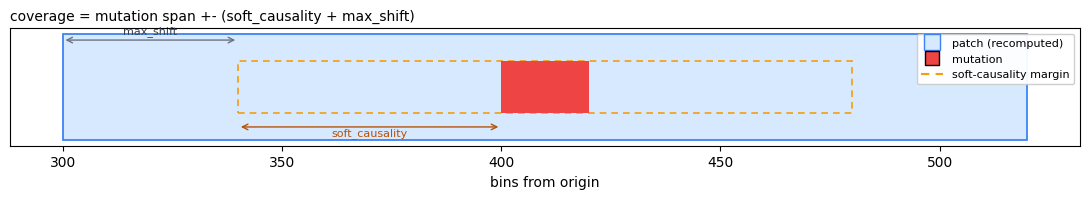

patch window (bins): [(300, 520)] -> width 220 bins


In [3]:
fig, ax = plt.subplots(figsize=(11, 2.1))
mut = [('replace', 400*BIN, 'A'*(20*BIN))]
sc, ms = 60*BIN, 40*BIN
pw = auto_patch_windows(mut, soft_causality_bp=sc, max_shift_bp=ms)
draw(ax, mut, pw, soft_causality_bp=sc, title='coverage = mutation span +- (soft_causality + max_shift)')
lo, hi = mutation_span(mut[0]); pl, pr = pw[0]
ax.annotate('', xy=(_b(pl,0),0.9), xytext=(_b(lo-sc,0),0.9), arrowprops=dict(arrowstyle='<->', color='#6b7280'))
ax.text((_b(pl,0)+_b(lo-sc,0))/2, 0.96, 'max_shift', ha='center', fontsize=8, color='#374151')
ax.annotate('', xy=(_b(lo-sc,0),0.16), xytext=(_b(lo,0),0.16), arrowprops=dict(arrowstyle='<->', color='#b45309'))
ax.text((_b(lo-sc,0)+_b(lo,0))/2, 0.09, 'soft_causality', ha='center', fontsize=8, color='#b45309')
ax.set_xlim(_b(pl,0)-12, _b(pr,0)+12); ax.legend(handles=LEGEND, loc='upper right', fontsize=8, framealpha=0.95)
plt.tight_layout(); plt.show()
print('patch window (bins):', [(l//BIN, h//BIN) for l,h in pw], '-> width', (pr-pl)//BIN, 'bins')

## 2. Laying MicroZoi tiles over the coverage (greedy)
`tile_pattern` covers the region with concrete MicroZoi tiles (bricks). It's **greedy**: while stepping tiles across a window, if the next window starts *before* the current tile run ends, it keeps tiling straight into it instead of starting a fresh (redundant) tile. So two ~1.1-tile windows 0.2 tile apart cost **3 tiles, not 4** — but two windows a full tile apart stay separate (4 tiles). This is the whole reason the merge lives here, not on the GPU: it needs the tile size, and it's deterministic.

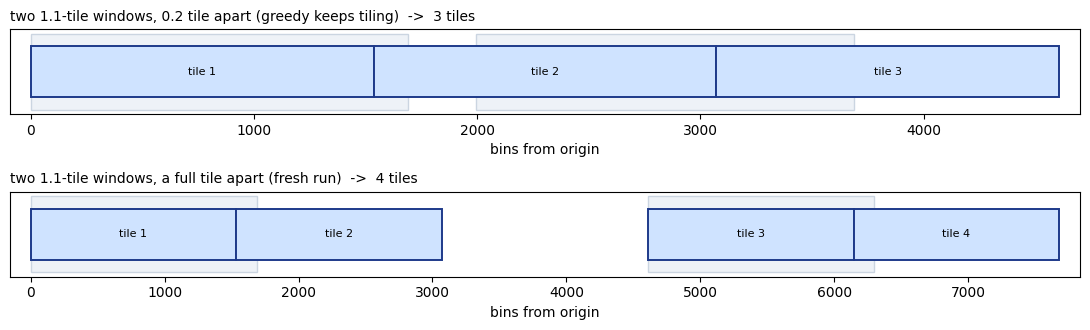

light grey = coverage that must be recomputed; blue = the MicroZoi tiles that cover it


In [4]:
step = tile_size_bp()
def draw_tiles(ax, coverage, title):
    tiles = tile_pattern(coverage)
    for lo, hi in coverage:
        ax.add_patch(Rectangle((lo/BIN, 0.05), (hi-lo)/BIN, 0.9, fc='#eef2f7', ec='#cbd5e1', lw=1, zorder=0))
    for i, (lo, hi) in enumerate(tiles):
        ax.add_patch(Rectangle((lo/BIN, 0.2), (hi-lo)/BIN, 0.6, fc='#cfe3ff', ec='#1e3a8a', lw=1.4, zorder=2))
        ax.text((lo+hi)/2/BIN, 0.5, f'tile {i+1}', ha='center', va='center', fontsize=8)
    hi_max = max(h for _, h in tiles) / BIN
    ax.set_xlim(-hi_max*0.02, hi_max*1.02); ax.set_ylim(0, 1); ax.set_yticks([])
    ax.set_xlabel('bins from origin'); ax.set_title(f'{title}  ->  {len(tiles)} tiles', loc='left', fontsize=10)

covA, covB = (0, int(1.1*step)), (int(1.3*step), int(2.4*step))   # 0.2 tile apart -> merge
covC = (int(3.0*step), int(4.1*step))                             # a full tile past -> separate
fig, axes = plt.subplots(2, 1, figsize=(11, 3.4))
draw_tiles(axes[0], [covA, covB], 'two 1.1-tile windows, 0.2 tile apart (greedy keeps tiling)')
draw_tiles(axes[1], [covA, covC], 'two 1.1-tile windows, a full tile apart (fresh run)')
plt.tight_layout(); plt.show()
print('light grey = coverage that must be recomputed; blue = the MicroZoi tiles that cover it')

## 3. The rigid shift never breaks causality
L1 shifts the **whole tile pattern** rigidly by the per-background offset (equivalently, the mutation sits at a different place within the fixed pattern — shown at `-max`, `0`, `+max`). The distance from the mutation to the nearest recomputed/cached seam stays **≥ `soft_causality`**, because the pattern was built with `max_shift` of headroom. The shift is a pure translation, yet it still augments: the mutation lands at a different phase within its tile, i.e. a different receptive field.

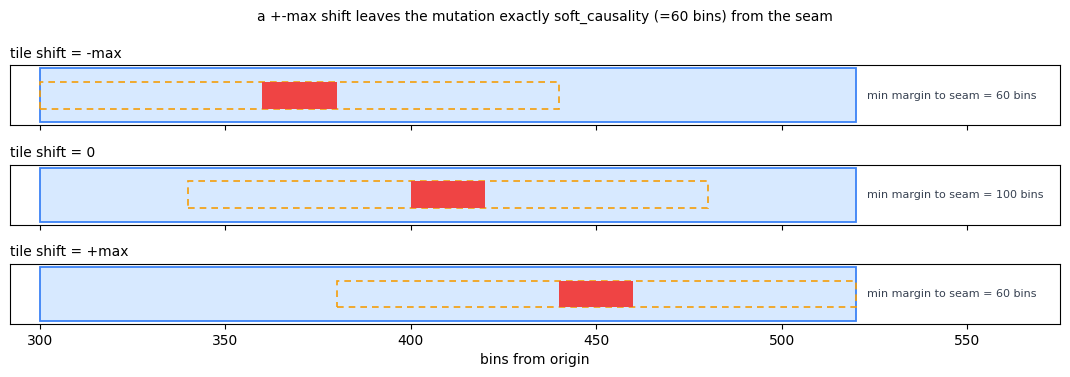

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 3.8), sharex=True)
sc, ms = 60*BIN, 40*BIN
pw = auto_patch_windows([('replace', 400*BIN, 'A'*(20*BIN))], soft_causality_bp=sc, max_shift_bp=ms)
for ax, off, lab in [(axes[0], -40, 'tile shift = -max'), (axes[1], 0, 'tile shift = 0'), (axes[2], +40, 'tile shift = +max')]:
    sm = [('replace', (400+off)*BIN, 'A'*(20*BIN))]
    draw(ax, sm, pw, soft_causality_bp=sc, title=lab)
    lo, hi = mutation_span(sm[0]); pl, pr = pw[0]; margin = min(lo-pl, pr-hi)//BIN
    ax.text(_b(pr,0)+3, 0.5, f'min margin to seam = {margin} bins', va='center', fontsize=8, color='#374151')
    ax.set_xlim(_b(pl,0)-8, _b(pr,0)+55)
axes[0].set_xlabel(''); axes[1].set_xlabel('')
fig.suptitle('a +-max shift leaves the mutation exactly soft_causality (=60 bins) from the seam', fontsize=10)
plt.tight_layout(); plt.show()

## 4. A rejected layout
`validate_patches` refuses a tile pattern whose edge falls inside a mutation's causality margin. Here a tile run starting at bin 102 leaves the mutation at 110 (and all of the mutation at 90) with stale wild-type activations — so it raises, with a message that says exactly what is uncovered.

rejected: soft-causality violation: mutation replace at [23040, 23296) needs bins [20480, 25856) recomputed (soft_causality 2560 + max_shift 0 bp), but that is not covered by a single contiguous run of tiles ((26112, 51456),). Widen the pattern, or lower soft_causality/max_shift.


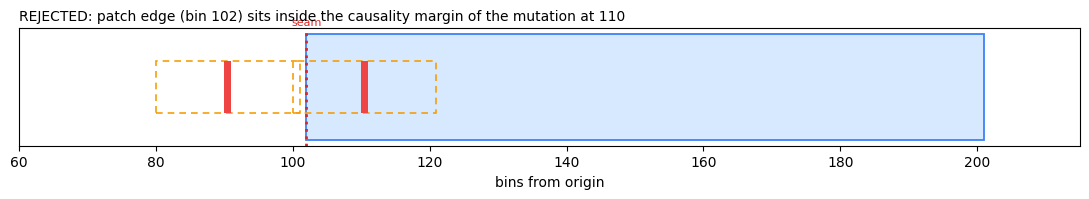

In [6]:
muts = [('replace', 90*BIN, 'A'*BIN), ('replace', 110*BIN, 'A'*BIN)]
bad = [(102*BIN, 201*BIN)]
try:
    validate_patches(muts, bad, soft_causality_bp=10*BIN, max_shift_bp=0)
except ValueError as e:
    print('rejected:', e)
fig, ax = plt.subplots(figsize=(11, 2.1))
draw(ax, muts, bad, soft_causality_bp=10*BIN, title='REJECTED: patch edge (bin 102) sits inside the causality margin of the mutation at 110')
ax.axvline(102, color='#dc2626', lw=2, ls=':'); ax.text(102, 1.03, 'seam', color='#dc2626', ha='center', fontsize=8)
ax.set_xlim(60, 215); plt.tight_layout(); plt.show()

## 5. Freezing random mutations
`shuffle` and `inactivate` are *random* by design. To keep a spec deterministic (and to reuse the exact same edit across a WT/mutant pair), `freeze_mutations` resolves them to a concrete `replace`. Freeze several times to average over realizations — e.g. inactivating an element with different inert sequences.

In [7]:
mut = (('inactivate', 1_000_000, 1_000_030),)
for i in range(3):
    op, pos, seq = freeze_mutations(mut, rng=np.random.default_rng(i))[0]
    print(f'inactivate realization {i}: replace @ {pos} -> {seq}')
class FakeFasta:
    def fetch(self, c, lo, hi): return ('ACGTTGCA'*(hi-lo))[:hi-lo]
print('shuffle2 ->', freeze_mutations((('shuffle2', 1000, 1030),), fasta=FakeFasta(), chrom='chr1', rng=np.random.default_rng(0))[0])
print('replace/invert pass through:', freeze_mutations((('invert', 200, 300),)))

inactivate realization 0: replace @ 1000000 -> AGATTCACAAGAATCCTAAATATATATGTT
inactivate realization 1: replace @ 1000000 -> TAACGCGAGCTCATCCTATTTTAGCAAAGA
inactivate realization 2: replace @ 1000000 -> GTCTCTCCCATAATCCTAAAGATAACATTT
shuffle2 -> ('replace', 1000, 'ACACGTGTTGCAAACGTGCAACGCGTTTTG')
replace/invert pass through: (('invert', 200, 300),)


## 6. The three use cases, as specs
Everything above composes into the actual workflows. A **background** fixes the cache read + patch geometry; **variants** fan it into WT / mutant conditions sharing it (so their difference is clean).

In [8]:
start = 20_000_000
mut = (('inactivate', start+2_000_000, start+2_000_400),)
frozen = freeze_mutations(mut, rng=np.random.default_rng(0))

# UC3 - simple matched pair (one background)
bg = background_for('chr1', start, run_idx=0, mutations_superset=frozen)
pair = variant_specs(bg, {'wt': None, 'mut': frozen})
print('UC3 matched pair:', [(s.tags['variant'], len(s.mutations)) for s in pair])

# UC1 - 4 pairs, distinct cache runs, shared mutation, random symmetric tile shift
bgs = random_backgrounds('chr1', start, runs=4, rng=np.random.default_rng(1), mutations_superset=frozen)
uc1 = [s for b in bgs for s in variant_specs(b, {'wt': None, 'mut': frozen})]
print('UC1 sweep:', len(uc1), 'specs; (run_idx, tile_offset_bins) =', [(b.run_idx, b.tile_offset_bins) for b in bgs])

# UC2 - all pairwise combos of 3 sites, ONE fixed patch set (no drift across conditions)
sites = [start+1_000_000, start+1_050_000, start+1_100_000]
superset = tuple(('inactivate', s, s+300) for s in sites)
bg2 = background_for('chr1', start, run_idx=0, mutations_superset=superset)
combos = {'+'.join(f'{(s-start)//1000}k' for s in c): freeze_mutations(tuple(('inactivate', s, s+300) for s in c), rng=np.random.default_rng(2))
          for r in (1, 2) for c in itertools.combinations(sites, r)}
uc2 = variant_specs(bg2, {'wt': None, **combos})
print('UC2 combos:', len(uc2), 'conditions share', len(bg2.tiles), 'fixed tiles (bins):', [(l//BIN, h//BIN) for l,h in bg2.tiles])

UC3 matched pair: [('wt', 0), ('mut', 1)]
UC1 sweep: 8 specs; (run_idx, tile_offset_bins) = [(0, -14), (1, 6), (2, 131), (3, 231)]
UC2 combos: 7 conditions share 1 fixed tiles (bins): [(81519, 83055)]


## Verdict
The vocabulary is three nouns — **mutation**, **tile pattern**, **background** — and one derived rule (`tolerance = soft_causality + max_shift`). The pattern (including the greedy tile merge) is worked out here, deterministically; L1 just rigidly shifts and runs it. Randomness is generated as concrete specs upstream; averaging collapses them downstream. Everything a sweep needs is a list of specs; nothing here needs a GPU to reason about. Not a behemoth.